In [1]:
import sys
sys.path.insert(0, '/home/jonathan/Documents/mi3-gs/build/python')
sys.path.append("..")

import drjit as dr
import mitsuba as mi
from drjit.auto import Float, UInt, Bool
mi.set_variant('cuda_ad_rgb')

%load_ext autoreload
%autoreload 2

jit_find_library(): Unable to load "/usr/lib/llvm-15/lib/libLLVM.so": /home/jonathan/miniconda3/envs/volprim/lib/python3.11/site-packages/zmq/backend/cython/../../../../.././libstdc++.so.6: version `GLIBCXX_3.4.30' not found (required by /usr/lib/llvm-15/lib/libLLVM.so)!


In [2]:
import volprim
from volprim.integrators.common import *

In [3]:
from scripts.radiosity.radiance_cache import RadianceCache
from scripts.radiosity.surface_sampler import SceneSurfaceSampler
from scripts.radiosity.vertex_bsdf import Diffuse, Principled

scene_path = "/home/jonathan/Documents/volprim-balance/scenes/mitsuba/cabinet/scene_remesh.xml"
scene = mi.load_file(scene_path)
gs_path = "/home/jonathan/Documents/gaussian-splatting-exr/output/cabinet_logL1_static-SSIM_hdrPcd_envImpt/point_cloud/iteration_30000/point_cloud.ply"

radiance_cache = RadianceCache(scene, gs_path)
scene_sampler = SceneSurfaceSampler(scene, mesh_indexes=[0])
bsdf_train = Diffuse()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..99.83729].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..100.0].


Pointwise energy missing (rel.): -0.226134
Pointwise energy abs diff. (rel.): 0.48578
Hemispheric integral: [[2.11767, 1.02056, 0.989566]] vs. [[2.73476, 1.32835, 1.25421]]


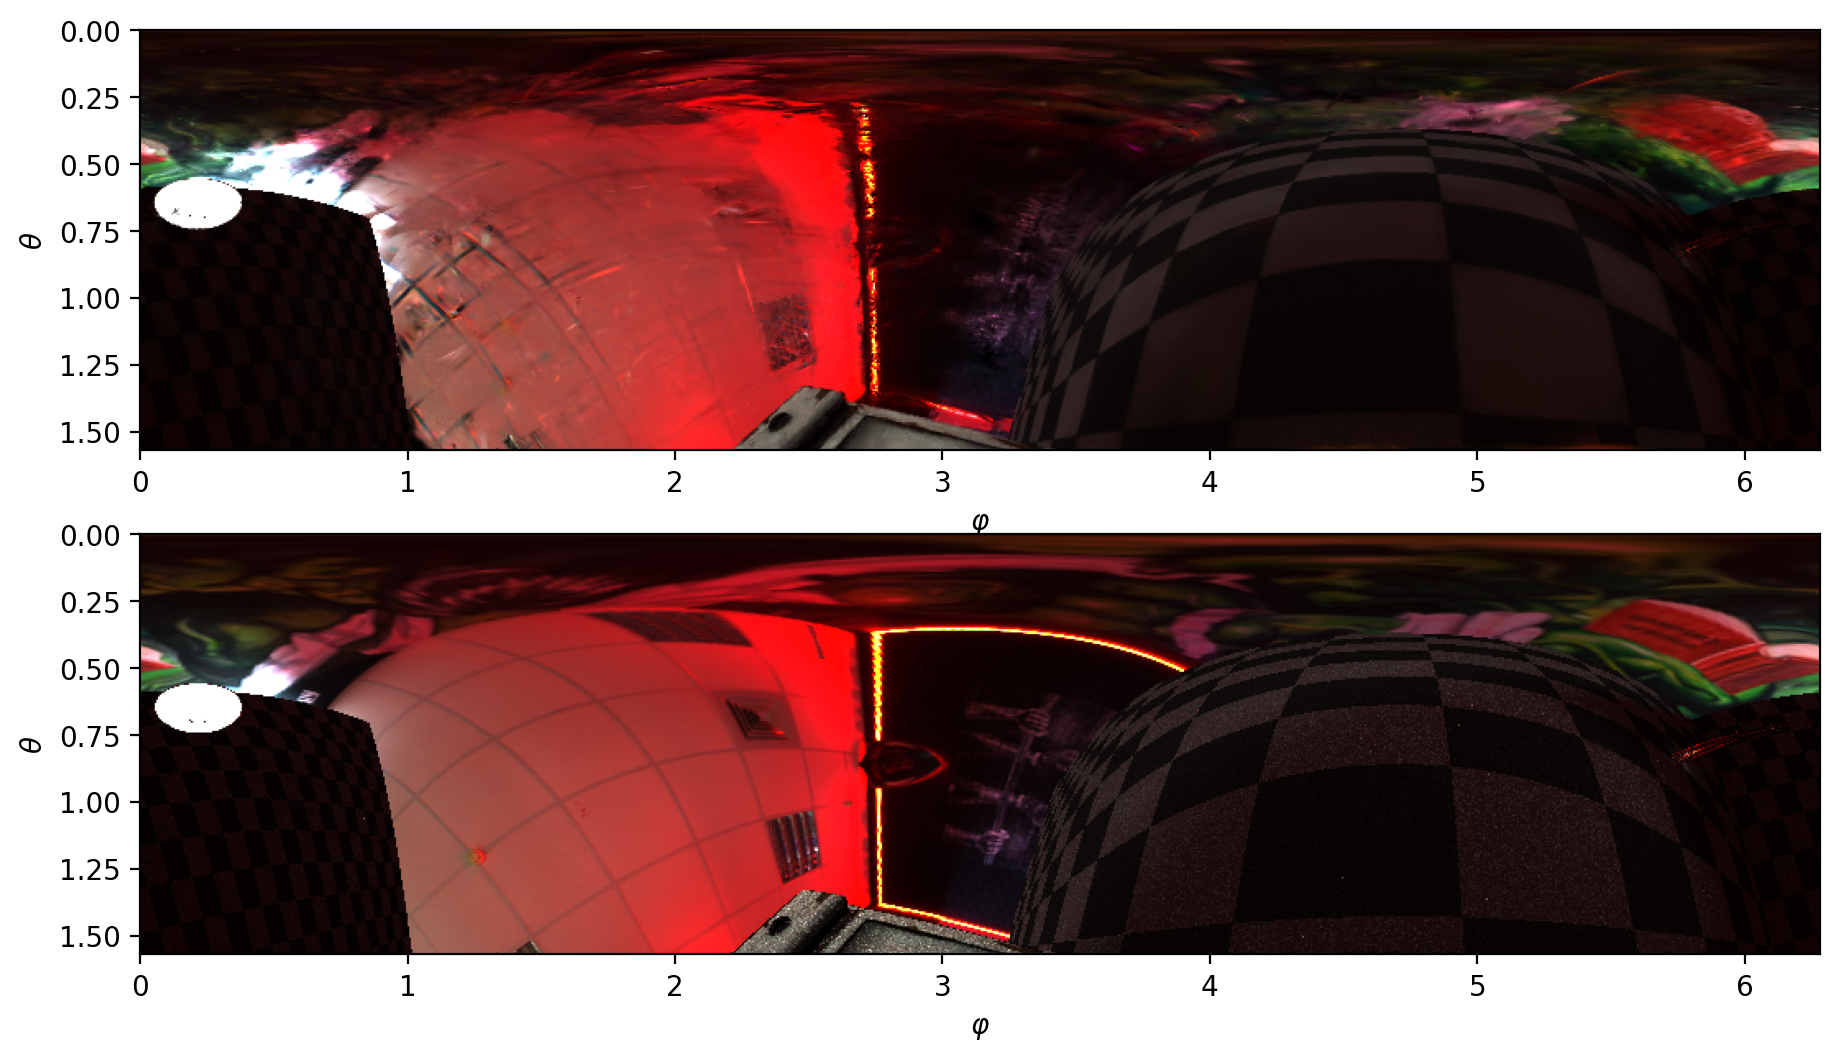

In [4]:
from scripts.radiosity.radiance_cache import render_hemisphere_rt, dir_to_sph, SamplingMethod
import matplotlib.pyplot as plt

sampler = mi.load_dict({'type': 'independent'})
seed = 200
si = scene_sampler.sample(1 << 0, sampler, rng_state=seed)[0]

N = 256
plt.figure(figsize=(13,6), dpi=200)
plt.subplot(211)
img_out, rays, I_out = radiance_cache._render_hemisphere_auto_offset(si, sampler, N)
plt.imshow(img_out, extent=[0, dr.two_pi, 0.5 * dr.pi, 0.0])
plt.xlabel(r"$\varphi$"); plt.ylabel(r"$\theta$")
mi.util.write_bitmap("fisheye_gs.exr", mi.Bitmap(img_out))

plt.subplot(212)
img_gt, rays, I_gt = render_hemisphere_rt(scene, si, sampler, N, spp = 256)
plt.imshow(img_gt, extent=[0, dr.two_pi, 0.5 * dr.pi, 0.0])
plt.xlabel(r"$\varphi$"); plt.ylabel(r"$\theta$")
mi.util.write_bitmap("fisheye_rt.exr", mi.Bitmap(img_gt))

print(f"Pointwise energy missing (rel.): {dr.sum(img_out - img_gt, axis=None) / dr.sum(img_gt, axis=None)}")
print(f"Pointwise energy abs diff. (rel.): {dr.sum(dr.abs(img_out - img_gt), axis=None) / dr.sum(img_gt, axis=None)}")
print(f"Hemispheric integral: {I_out} vs. {I_gt}")

In [126]:
class ReservoirVector3f:
    DRJIT_STRUCT = {
        'sample': mi.Vector3f,
        'valid': bool,
        'w_sum': Float,
        'p_hat': Float,
        'c': Float,
    }

    def __init__(self, size: int):
        self.sample = dr.zeros(mi.Vector3f, size)
        self.valid = dr.full(Bool, False, size)
        self.w_sum = dr.zeros(Float, size)
        self.p_hat = dr.zeros(Float, size)
        self.c     = dr.zeros(Float, size)

    def add_proposal(self, direction: mi.Vector3f, rand: Float, weight: Float, confidence: float = 1.0):
        self.w_sum += weight
        cond = (self.w_sum > 0.0) & (rand < weight * dr.rcp(self.w_sum))
        self.sample = dr.select(cond, direction, self.sample)
        self.valid |= weight > 0.0
        self.c = dr.minimum(self.c + confidence, 20.0)
    
    def size(self):
        return dr.width(self.sample)
    
    # def eval_target(self, eval_target_function):
    #     self.p_hat = dr.select(self.valid, eval_target_function(self.sample), 0.0)

    def get_sample(self, eval_target):
        p_hat = dr.select(self.valid, eval_target(self.sample), 0.0)
        W = dr.select(p_hat > 0.0, self.w_sum * dr.rcp(p_hat), 0.0)
        self.p_hat = p_hat
        return self.sample, W
    
    def reinitialize(self, mis_weight):
        # # update sample; no-op
        # self.sample = self.sample

        # update `w_sum`
        self.w_sum = dr.select(self.p_hat > 0.0, mis_weight * self.w_sum, 0.0)

        # update `valid`
        self.valid = self.w_sum > 0.0

In [134]:
def eval_target_function(d: mi.Vector3f, si: mi.SurfaceInteraction3f, radiance_cache: RadianceCache, sampler: mi.Sampler, rng_state: int = 0):
        ray = radiance_cache._spawn_offset_ray(si, d)
        Le, rng_state = radiance_cache._pathtrace(ray, sampler, rng_state)
        # Le = mi.Color3f(1.0,1.0,1.0)
        p_hat = dr.max(Le, axis=0)
        return p_hat

def proposal_direction(sample2: mi.Point2f):
     d = mi.warp.square_to_uniform_hemisphere(sample2)
     pdf = mi.warp.square_to_uniform_hemisphere_pdf(d)
     return d, pdf


rsv_curr = ReservoirVector3f(dr.width(si))


def run(radiance_cache, si, sampler, M):
    for _ in range(M):
        # Draw a sample from the proposal distribution
        d_sample, pdf = proposal_direction(sampler.next_2d())
        # Contrib. weight of drawn sample, `s.W`
        ds_W = dr.rcp(pdf)
        # Compute `p_hat`: target function *without* visibility
        p_hat = eval_target_function(d_sample, si, radiance_cache, sampler)
        # Compute weight `w`
        mis_weight = 1.0 / M
        w = dr.select(pdf > 0.0, mis_weight * p_hat * ds_W, 0.0)
        # Add sample to reservoir
        rsv_curr.add_proposal(d_sample, sampler.next_1d(), w, 1.0)

    d, contrib_weight = rsv_curr.get_sample(lambda ds: eval_target_function(ds, si, radiance_cache, sampler))

    ray = radiance_cache._spawn_offset_ray(si, d)
    integrand, rng_state = radiance_cache._pathtrace(ray, sampler, rng_state)
    result = integrand * contrib_weight
    return result


M = 64

print(result)

[[0.525559, 0.272397, 0.80597]]


KeyboardInterrupt: 

In [8]:
def eval_target_function(d: mi.Vector3f, si: mi.SurfaceInteraction3f, radiance_cache: RadianceCache, sampler: mi.Sampler, rng_state: int = 0):
        ray = radiance_cache._spawn_offset_ray(si, d)
        Le, rng_state = radiance_cache._pathtrace(ray, sampler, rng_state)
        p_hat = dr.max(Le, axis=0)
        return p_hat

def proposal_direction(sample2: mi.Point2f):
     d = mi.warp.square_to_uniform_hemisphere(sample2)
     pdf = mi.warp.square_to_cosine_hemisphere_pdf(d)
     return d, pdf

def emRIS(radiance_cache: RadianceCache, si: mi.SurfaceInteraction3f, sampler: mi.Sampler, M: int, rsv_prev: ReservoirVector3f = None):
    # Handle direct hit on emitter
    result = dr.zeros(mi.Color3f, dr.width(si))

    # --------------- Sample generation for emitters ---------------
    # Populate `rsv_curr` with the current iteration's proposals/candidates
    rsv_curr = ReservoirVector3f(dr.width(si))
    for _ in range(M):
        # Draw a sample from the proposal distribution
        d_sample, pdf = proposal_direction(sampler.next_2d())
        # Contrib. weight of drawn sample, `s.W`
        ds_W = dr.rcp(pdf)
        # Compute `p_hat`: target function *without* visibility
        p_hat = eval_target_function(d_sample, si, radiance_cache, sampler)
        # Compute weight `w`
        mis_weight = 1.0 / M
        w = dr.select(pdf > 0.0, mis_weight * p_hat * ds_W, 0.0)
        # Add sample to reservoir
        rsv_curr.add_proposal(d_sample, sampler.next_1d(), w, 1.0)

    # if rsv_prev is not None:
    #     rsv_curr.eval_target(lambda ds: eval_target_function(ds, si, bsdf))
    #     # --------------- Temporal reuse ---------------
    #     # Adjust `rsv_curr` to account for the addition of the previous iteration's 
    #     # reservoir. Then, merge it with this previous reservoir.
    #     prev_c = dr.minimum(rsv_prev.c, 20.0 * rsv_curr.c)
    #     # mis_curr = balance_heuristic(rsv_curr.p_hat * rsv_curr.c, rsv_prev.p_hat * prev_c)   # TODO
    #     mis_curr = balance_heuristic(rsv_curr.p_hat, rsv_prev.p_hat)   # TODO
    #     rsv_curr.reinitialize(mis_curr)

    #     # Add previous iteration's reservoir
    #     mis_prev = 1.0 - mis_curr                               # TODO
    #     w = dr.select(rsv_prev.p_hat > 0.0, mis_prev * rsv_prev.w_sum, 0.0)
    #     rsv_curr.add_proposal(rsv_prev.sample, sampler.next_1d(), w, rsv_prev.c)

    #     return mi.Color3f(mis_curr, mis_curr, mis_curr), rsv_curr
    
    # Draw sample from the reservoir
    d, contrib_weight = rsv_curr.get_sample(lambda ds: eval_target_function(ds, si, radiance_cache, sampler))

    # --------------------- Evaluate integrand ----------------------
    ray = radiance_cache._spawn_offset_ray(si, d)
    integrand, rng_state = radiance_cache._pathtrace(ray, sampler, rng_state)
    result += dr.sum(integrand * contrib_weight)

    # wo = si.to_local(ds.d)
    # bsdf_val = bsdf.eval(ctx, si, wo)
    # Le_val = ds.emitter.eval_direction(si, ds)
    # # Evaluate visibility
    # occluded = scene.ray_test(si.spawn_ray_to(ds.p))
    # integrand = dr.select(~occluded, bsdf_val * Le_val, mi.Color3f(0.0))
    # result += dr.select(active, integrand * contrib_weight, 0.0)

    # # ------ Finalize ------
    return result, rsv_curr

# M = 8
# emRIS(radiance_cache, si, sampler, M)